## **1. IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)


## **2. MEMUAT DATA DAN INTEGRASI (*TWO-STAGE MODELING*)**

In [2]:
# ====== INTEGRASI DATA PELANGGAN + KELUHAN (Sesuai Jurnal Siregar) ======
# Jurnal: Tabel 1 -> Nama | Lama Berlangganan | Paket | Keluhan | Status Churn
# Keluhan berasal dari output Pipeline NLP (severity level 1-4)

# 1. Load data pelanggan (data utama)
df_pelanggan = pd.read_csv('../dataset/data_pelanggan.csv')
print(f'Data pelanggan: {df_pelanggan.shape[0]:,} baris')
display(df_pelanggan.head(3))

# 2. Load output NLP: severity per user (dari NLP_Pipeline.ipynb)
nlp_path = '../output/severity_per_user.csv'
if not os.path.exists(nlp_path):
    nlp_path = '../dummy/severity_per_user.csv'  # fallback
df_nlp = pd.read_csv(nlp_path)
df_nlp.rename(columns={'predicted_severity': 'keluhan'}, inplace=True)
df_nlp['keluhan'] = df_nlp['keluhan'].astype(int)
print(f'\nData keluhan (output NLP): {df_nlp.shape[0]:,} user')
display(df_nlp.head(3))

# 3. Merge: data_pelanggan + keluhan (Left Join)
#    Pelanggan tanpa keluhan → default level 1 (No Explicit Reproach)
df_merge = df_pelanggan.merge(df_nlp, on='kode_user', how='left')
df_merge['keluhan'] = df_merge['keluhan'].fillna(1).astype(int)

# 4. Tampilkan hasil integrasi (sesuai Tabel 1 jurnal Siregar)
print(f'\nHasil Integrasi Data (sesuai jurnal):')
print(f'Total pelanggan: {df_merge.shape[0]:,}')
display(df_merge[['kode_user', 'paket_satuan', 'lama_aktivasi', 'keluhan', 'status_log']].head(10))

print(f'\nDistribusi keluhan:')
display(df_merge['keluhan'].value_counts().sort_index().to_frame('Jumlah'))


Data pelanggan: 4,100 baris


,id,kode_user,paket_satuan,status_log,lama_aktivasi
0,1,GI0042,5 Mbps,y,55 bulan
1,2,GI0035,10 Mbps,y,55 bulan
2,3,GI0046,10 Mbps,y,55 bulan



Data keluhan (output NLP): 1,670 user


,kode_user,keluhan
0,AT0003,1
1,AT0013,1
2,AT0019,1



Hasil Integrasi Data (sesuai jurnal):
Total pelanggan: 4,100


,kode_user,paket_satuan,lama_aktivasi,keluhan,status_log
0,GI0042,5 Mbps,55 bulan,2,y
1,GI0035,10 Mbps,55 bulan,1,y
2,GI0046,10 Mbps,55 bulan,2,y
3,GI0047,10 Mbps,55 bulan,1,n
4,GJ0071,10 Mbps,55 bulan,2,y
5,GJ0063,10 Mbps,55 bulan,1,y
6,GJ0054,5 Mbps,55 bulan,1,y
7,GJ0002,10 Mbps,55 bulan,2,y
8,GJ0004,15 Mbps,55 bulan,2,y
9,GJ0019,5 Mbps,55 bulan,1,y



Distribusi keluhan:


,Jumlah
keluhan,
1,2896
2,1071
3,33
4,100


## **3. FEATURE ENGINEERING DAN PRA-PEMROSESAN (LABEL CHURN)**

In [3]:
df_model = df_merge.copy()

# Ekstraksi 'lama_aktivasi' menjadi numerik (bulan)
df_model['lama_aktivasi_bulan'] = df_model['lama_aktivasi'].astype(str).str.extract(r'(\d+)').astype(float)
df_model['lama_aktivasi_bulan'] = df_model['lama_aktivasi_bulan'].fillna(df_model['lama_aktivasi_bulan'].median())

# Ekstraksi 'paket_satuan' menjadi numerik (Mbps)
df_model['paket_mbps'] = df_model['paket_satuan'].astype(str).str.extract(r'(\d+)').astype(float)
df_model['paket_mbps'] = df_model['paket_mbps'].fillna(df_model['paket_mbps'].median())

# Encoding target churn: status_log 'y' = aktif (0), lainnya = churn (1)
df_model['churn'] = np.where(df_model['status_log'].astype(str).str.lower().eq('y'), 0, 1)

# Variabel prediktor (X) dan target (y)
feature_cols = ['paket_mbps', 'lama_aktivasi_bulan', 'keluhan']
X = df_model[feature_cols]
y = df_model['churn']

print('Distribusi Label Churn:')
display(y.value_counts().to_frame('Jumlah'))
print(f'\nFitur yang digunakan: {feature_cols}')
display(X.describe().round(2))


Distribusi Label Churn:


,Jumlah
churn,
0,3691
1,409



Fitur yang digunakan: ['paket_mbps', 'lama_aktivasi_bulan', 'keluhan']


,paket_mbps,lama_aktivasi_bulan,keluhan
count,4100.00,4100.00,4100.00
mean,9.26,21.79,1.35
std,11.85,16.58,0.62
min,5.00,0.00,1.00
25%,5.00,9.00,1.00
50%,5.00,17.00,1.00
75%,10.00,33.00,2.00
max,100.00,55.00,4.00


## **4. EKSPLORASI DATA (VISUALISASI EDA)**

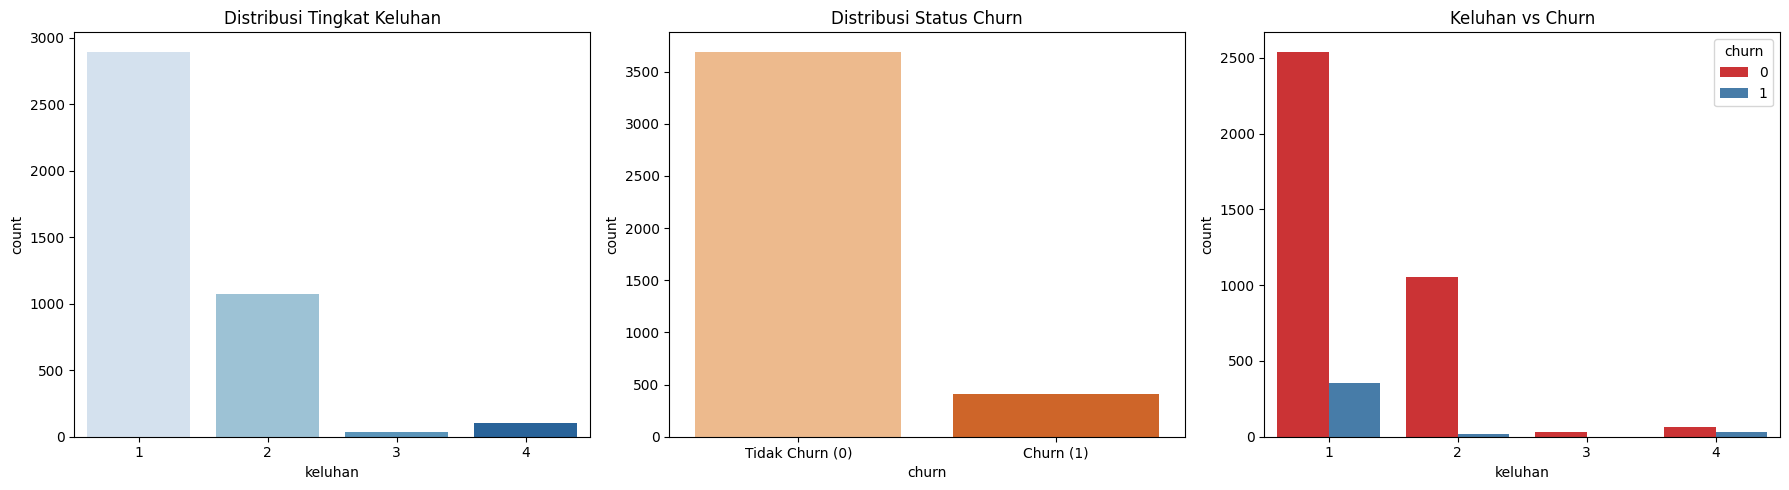

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi tingkat keluhan
sns.countplot(data=df_model, x='keluhan', palette='Blues', ax=axes[0])
axes[0].set_title('Distribusi Tingkat Keluhan')

# Distribusi status churn
sns.countplot(data=df_model, x='churn', palette='Oranges', ax=axes[1])
axes[1].set_title('Distribusi Status Churn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Tidak Churn (0)', 'Churn (1)'])

# Korelasi keluhan vs churn
sns.countplot(data=df_model, x='keluhan', hue='churn', palette='Set1', ax=axes[2])
axes[2].set_title('Keluhan vs Churn')
plt.tight_layout(); plt.show()


## **5. MODELING: PERANCANGAN ALGORITMA DECISION TREE**

In [5]:
# Train-Test Split 80:20 dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training: {X_train.shape[0]:,} | Testing: {X_test.shape[0]:,}')

# === Decision Tree (Entropy — sesuai jurnal 2698-8178-1-PB) ===
clf_dt = DecisionTreeClassifier(
    criterion='entropy',  # Information Gain
    max_depth=5,
    random_state=42
)
clf_dt.fit(X_train, y_train)
y_pred_dt = clf_dt.predict(X_test)
print('Decision Tree berhasil di-training.')

# === Random Forest (sesuai jurnal 978 Merkurius) ===
clf_rf = RandomForestClassifier(
    n_estimators=100,     # 100 pohon keputusan
    criterion='entropy',  # sama: Information Gain
    max_depth=5,
    random_state=42
)
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)
print('Random Forest berhasil di-training.')


Training: 3,280 | Testing: 820
Decision Tree berhasil di-training.
Random Forest berhasil di-training.


## **6. EVALUASI DAN AKURASI (ROC-AUC)**

===== DECISION TREE =====


,Accuracy,Precision,Recall,F1-Score
0,0.9061,0.6000,0.1829,0.2804


              precision    recall  f1-score   support

           0       0.92      0.99      0.95       738
           1       0.60      0.18      0.28        82

    accuracy                           0.91       820
   macro avg       0.76      0.58      0.62       820
weighted avg       0.88      0.91      0.88       820


===== RANDOM FOREST =====


,Accuracy,Precision,Recall,F1-Score
0,0.9037,1.0000,0.0366,0.0706


              precision    recall  f1-score   support

           0       0.90      1.00      0.95       738
           1       1.00      0.04      0.07        82

    accuracy                           0.90       820
   macro avg       0.95      0.52      0.51       820
weighted avg       0.91      0.90      0.86       820


===== PERBANDINGAN DECISION TREE vs RANDOM FOREST =====


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.9061,0.6000,0.1829,0.2804
1,Random Forest,0.9037,1.0000,0.0366,0.0706


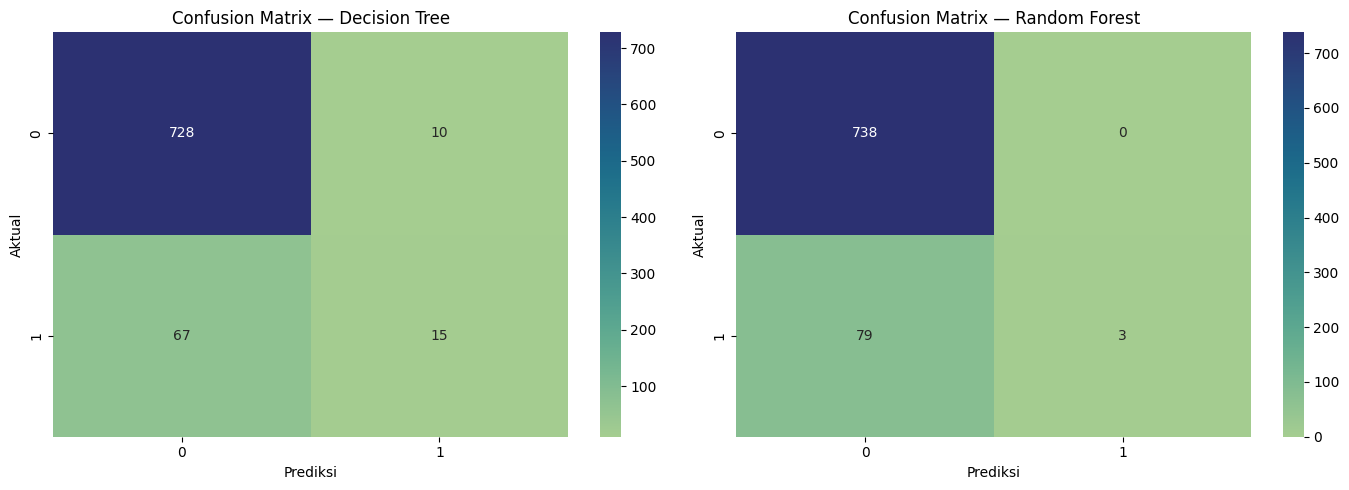

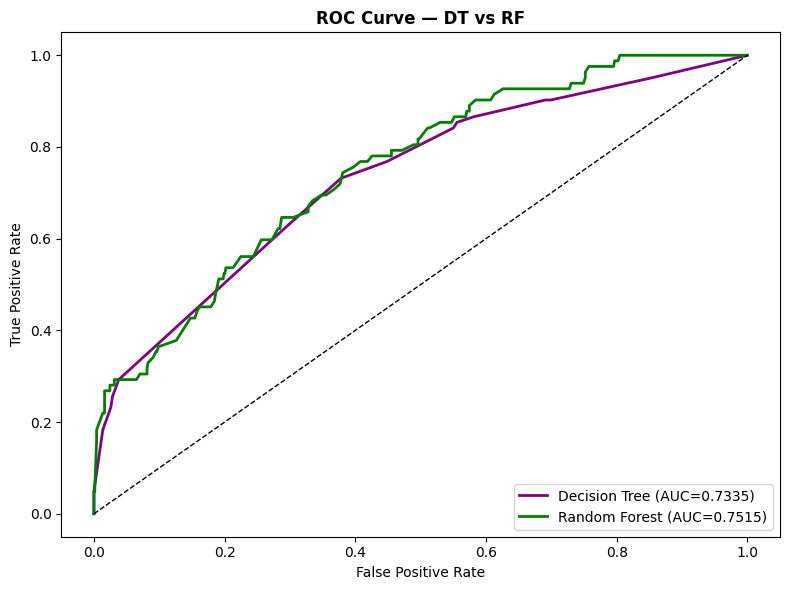

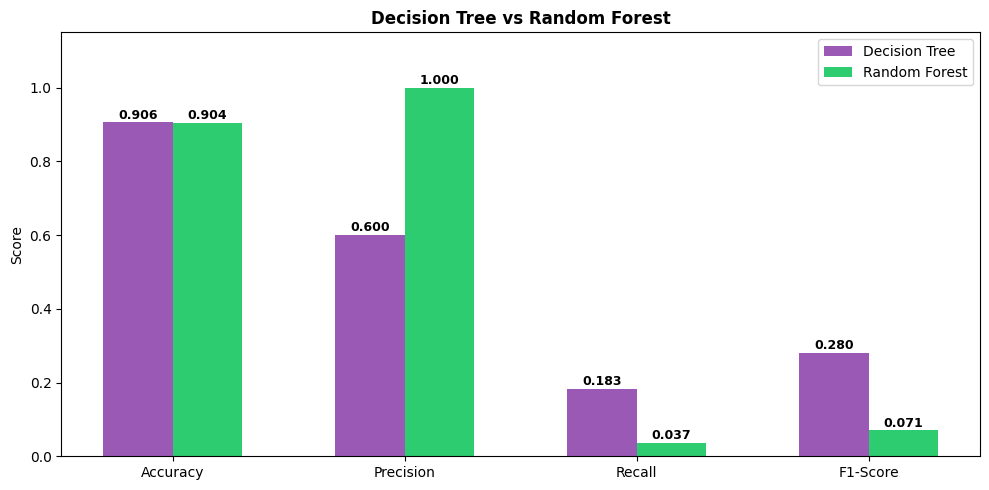

In [6]:
# === Evaluasi Decision Tree ===
print('===== DECISION TREE =====')
display(pd.DataFrame([{
    'Accuracy': f'{accuracy_score(y_test, y_pred_dt):.4f}',
    'Precision': f'{precision_score(y_test, y_pred_dt, zero_division=0):.4f}',
    'Recall': f'{recall_score(y_test, y_pred_dt, zero_division=0):.4f}',
    'F1-Score': f'{f1_score(y_test, y_pred_dt, zero_division=0):.4f}',
}]))
print(classification_report(y_test, y_pred_dt, zero_division=0))

# === Evaluasi Random Forest ===
print('\n===== RANDOM FOREST =====')
display(pd.DataFrame([{
    'Accuracy': f'{accuracy_score(y_test, y_pred_rf):.4f}',
    'Precision': f'{precision_score(y_test, y_pred_rf, zero_division=0):.4f}',
    'Recall': f'{recall_score(y_test, y_pred_rf, zero_division=0):.4f}',
    'F1-Score': f'{f1_score(y_test, y_pred_rf, zero_division=0):.4f}',
}]))
print(classification_report(y_test, y_pred_rf, zero_division=0))

# === PERBANDINGAN DT vs RF ===
print('\n===== PERBANDINGAN DECISION TREE vs RANDOM FOREST =====')
compare = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_dt, zero_division=0), precision_score(y_test, y_pred_rf, zero_division=0)],
    'Recall': [recall_score(y_test, y_pred_dt, zero_division=0), recall_score(y_test, y_pred_rf, zero_division=0)],
    'F1-Score': [f1_score(y_test, y_pred_dt, zero_division=0), f1_score(y_test, y_pred_rf, zero_division=0)],
})
display(compare.style.format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1-Score':'{:.4f}'}).highlight_max(axis=0, subset=['Accuracy','Precision','Recall','F1-Score']))

# === Visualisasi: Confusion Matrix DT vs RF ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, name in zip(axes, [y_pred_dt, y_pred_rf], ['Decision Tree', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest', ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout(); plt.show()

# === ROC Curve DT vs RF ===
fig, ax = plt.subplots(figsize=(8, 6))
for model, pred, name, color in [(clf_dt, y_pred_dt, 'Decision Tree', 'purple'),
                                   (clf_rf, y_pred_rf, 'Random Forest', 'green')]:
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — DT vs RF', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

# === Perbandingan Bar Chart ===
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics)); width = 0.3
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare[metrics].iloc[0], width, label='Decision Tree', color='#9b59b6')
bars2 = ax.bar(x + width/2, compare[metrics].iloc[1], width, label='Random Forest', color='#2ecc71')
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Decision Tree vs Random Forest', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


## **7. INTERPRETASI POIN POHON KEPUTUSAN DAN IMPORTANCE**

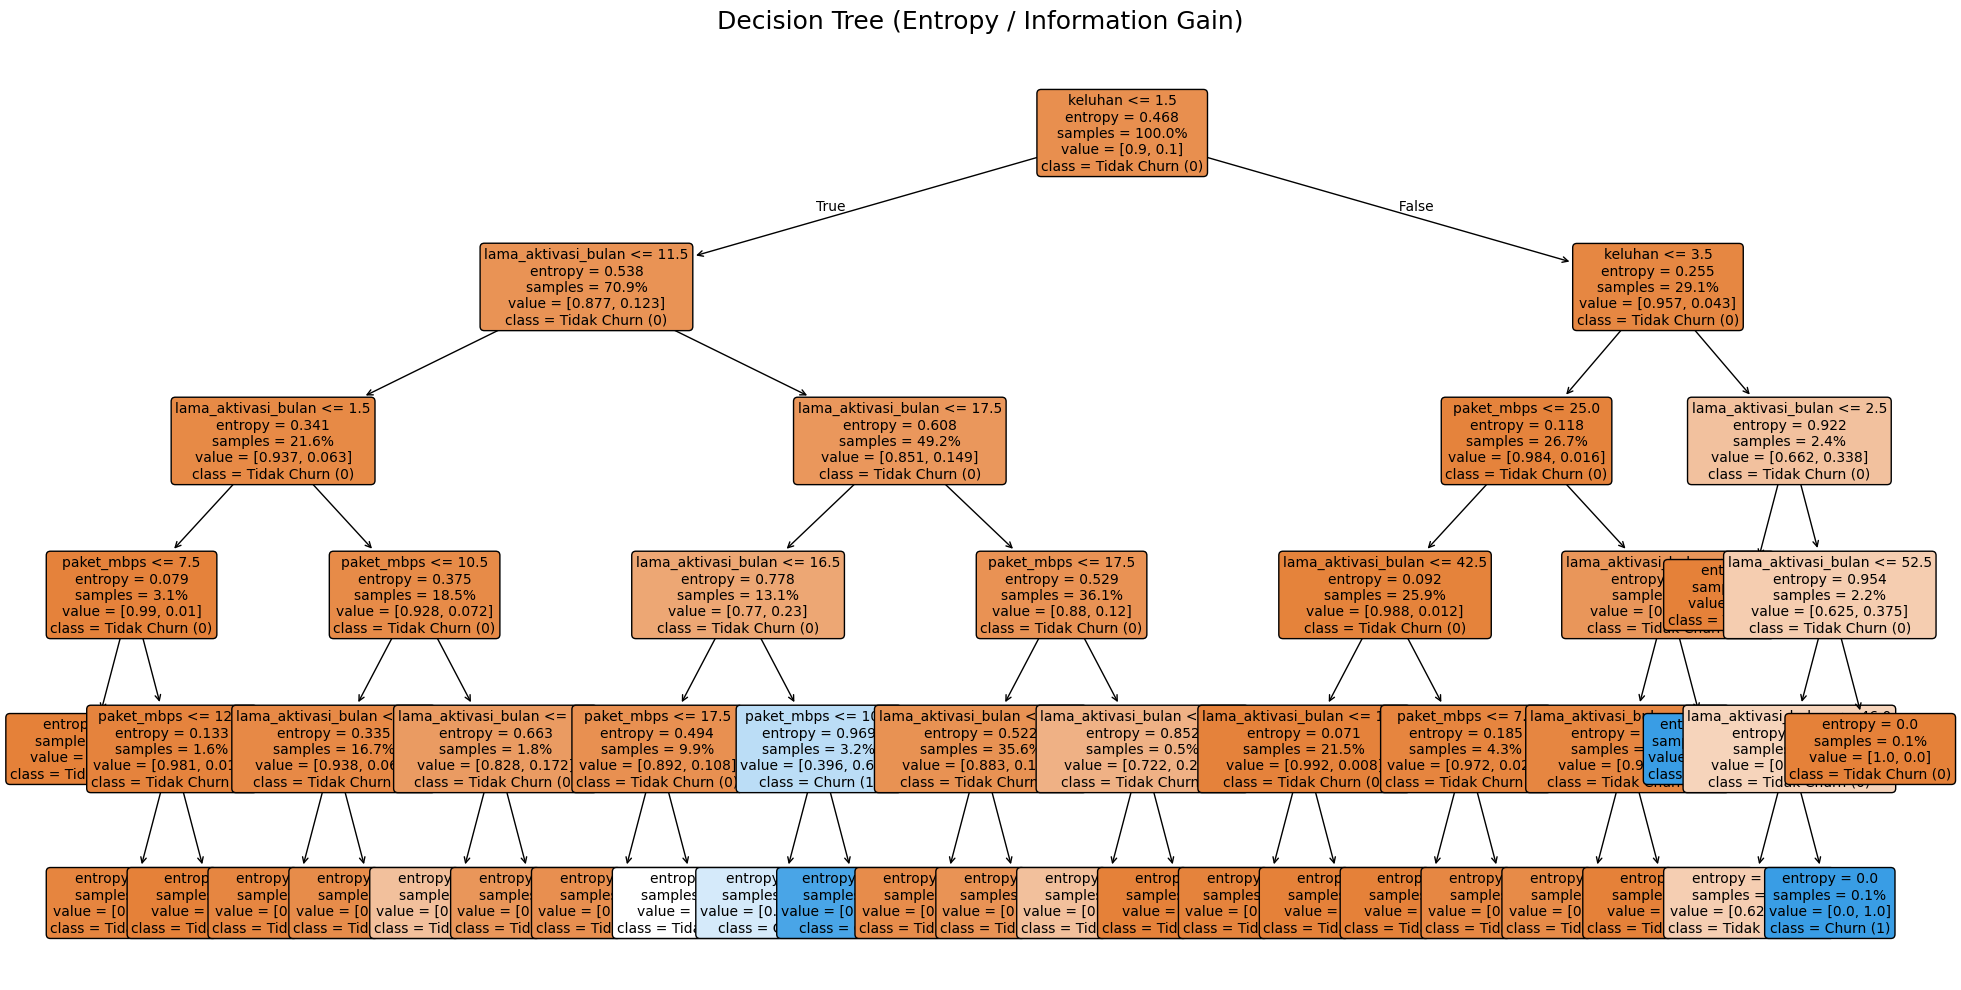

,Fitur,DT Importance,RF Importance
1,lama_aktivasi_bulan,0.539995,0.492764
2,keluhan,0.360737,0.357326
0,paket_mbps,0.099267,0.149910


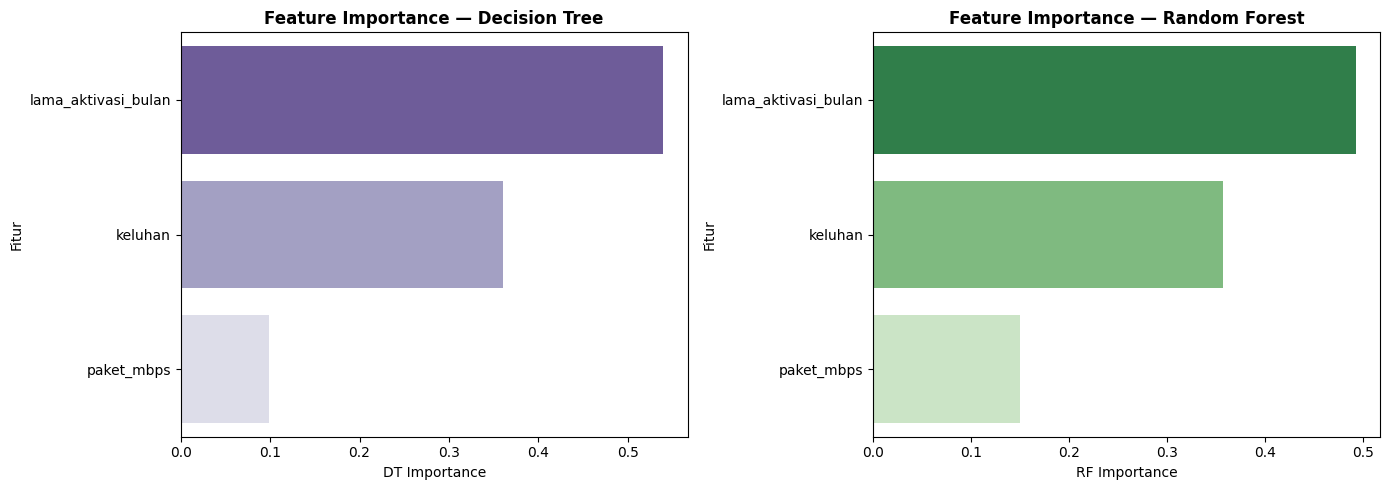

In [7]:
# 1. Plot Diagram Pohon Keputusan (Decision Tree)
plt.figure(figsize=(24, 12))
plot_tree(
    clf_dt,
    feature_names=feature_cols,
    class_names=['Tidak Churn (0)', 'Churn (1)'],
    filled=True, rounded=True, fontsize=10, proportion=True
)
plt.title('Decision Tree (Entropy / Information Gain)', fontsize=18, pad=20)
plt.show()

# 2. Feature Importance: DT vs RF
feat_compare = pd.DataFrame({
    'Fitur': feature_cols,
    'DT Importance': clf_dt.feature_importances_,
    'RF Importance': clf_rf.feature_importances_
}).sort_values('DT Importance', ascending=False)
display(feat_compare)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=feat_compare, x='DT Importance', y='Fitur', palette='Purples_r', ax=axes[0])
axes[0].set_title('Feature Importance — Decision Tree', fontweight='bold')
sns.barplot(data=feat_compare.sort_values('RF Importance', ascending=False),
            x='RF Importance', y='Fitur', palette='Greens_r', ax=axes[1])
axes[1].set_title('Feature Importance — Random Forest', fontweight='bold')
plt.tight_layout(); plt.show()


## **8. EKSPOR HASIL PREDIKSI KESELURUHAN (OUTPUT)**

In [8]:
# Prediksi churn pada seluruh dataset
df_model['pred_churn_dt'] = clf_dt.predict(X)
df_model['pred_churn_rf'] = clf_rf.predict(X)

# Simpan CSV
os.makedirs('../output', exist_ok=True)
df_model.to_csv('../output/data_churn_prediction.csv', index=False)
print('CSV tersimpan: output/data_churn_prediction.csv')

# Export model PKL untuk Streamlit dashboard
os.makedirs('../model', exist_ok=True)
with open('../model/decision_tree_churn.pkl', 'wb') as f:
    pickle.dump(clf_dt, f)
with open('../model/random_forest_churn.pkl', 'wb') as f:
    pickle.dump(clf_rf, f)
print('PKL tersimpan: model/decision_tree_churn.pkl & random_forest_churn.pkl')

display(df_model[['kode_user', 'paket_mbps', 'lama_aktivasi_bulan', 'keluhan',
                   'churn', 'pred_churn_dt', 'pred_churn_rf']].head(10))

# Ringkasan
print('\nDistribusi prediksi:')
display(pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Prediksi Churn': [(df_model['pred_churn_dt']==1).sum(), (df_model['pred_churn_rf']==1).sum()],
    'Prediksi Tidak Churn': [(df_model['pred_churn_dt']==0).sum(), (df_model['pred_churn_rf']==0).sum()]
}))


CSV tersimpan: output/data_churn_prediction.csv
PKL tersimpan: model/decision_tree_churn.pkl & random_forest_churn.pkl


,kode_user,paket_mbps,lama_aktivasi_bulan,keluhan,churn,pred_churn_dt,pred_churn_rf
0,GI0042,5.0,55.0,2,0,0,0
1,GI0035,10.0,55.0,1,0,0,0
2,GI0046,10.0,55.0,2,0,0,0
3,GI0047,10.0,55.0,1,1,0,0
4,GJ0071,10.0,55.0,2,0,0,0
5,GJ0063,10.0,55.0,1,0,0,0
6,GJ0054,5.0,55.0,1,0,0,0
7,GJ0002,10.0,55.0,2,0,0,0
8,GJ0004,15.0,55.0,2,0,0,0
9,GJ0019,5.0,55.0,1,0,0,0



Distribusi prediksi:


,Model,Prediksi Churn,Prediksi Tidak Churn
0,Decision Tree,136,3964
1,Random Forest,15,4085
